In [1]:
!pip install tensorflow
!pip install optuna
!pip install scikit-learn
!pip install split-folders

In [3]:
!curl -L -o ./brain-tumor-mri-dataset.zip https://www.kaggle.com/api/v1/datasets/download/masoudnickparvar/brain-tumor-mri-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  157M  100  157M    0     0  93.1M      0  0:00:01  0:00:01 --:--:--  132M


In [7]:
!unzip ./brain-tumor-mri-dataset.zip -d ./dataset

Streaming output truncated to the last 5000 lines.
  inflating: ./dataset/Training/glioma/Tr-gl_279.jpg  
  inflating: ./dataset/Training/glioma/Tr-gl_28.jpg  
  inflating: ./dataset/Training/glioma/Tr-gl_280.jpg  
  inflating: ./dataset/Training/glioma/Tr-gl_281.jpg  
  inflating: ./dataset/Training/glioma/Tr-gl_282.jpg  
  inflating: ./dataset/Training/glioma/Tr-gl_283.jpg  
  inflating: ./dataset/Training/glioma/Tr-gl_284.jpg  
  inflating: ./dataset/Training/glioma/Tr-gl_285.jpg  
  inflating: ./dataset/Training/glioma/Tr-gl_286.jpg  
  inflating: ./dataset/Training/glioma/Tr-gl_287.jpg  
  inflating: ./dataset/Training/glioma/Tr-gl_288.jpg  
  inflating: ./dataset/Training/glioma/Tr-gl_289.jpg  
  inflating: ./dataset/Training/glioma/Tr-gl_29.jpg  
  inflating: ./dataset/Training/glioma/Tr-gl_290.jpg  
  inflating: ./dataset/Training/glioma/Tr-gl_291.jpg  
  inflating: ./dataset/Training/glioma/Tr-gl_292.jpg  
  inflating: ./dataset/Training/glioma/Tr-gl_293.jpg  
  inflating: ./d

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import f1_score, roc_auc_score, recall_score, accuracy_score, classification_report, confusion_matrix


import splitfolders
import optuna
import numpy as np
import random

In [3]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("TF Version:", tf.__version__)
gpu = tf.config.list_physical_devices('GPU')
print(f"GPU Name: {tf.test.gpu_device_name()}")

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF Version: 2.20.0
GPU Name: /device:GPU:0


In [4]:
# ============================================
# CONFIGURATION
# ===========================================

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE=64
SEED = 42
NUM_CLASSES=4

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [7]:
def data_augmentation():
  # ============================================
  # IMAGE DATA GENERATOR
  # ===========================================

  train_datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    preprocessing_function=vgg_preprocess,
    validation_split=0.2,
  )

  validation_datagen = ImageDataGenerator(
    preprocessing_function=vgg_preprocess,
    validation_split=0.2,
  )

  test_datagen = ImageDataGenerator(
    preprocessing_function=vgg_preprocess,
  )

  # ============================================
  # LOAD IMAGE
  # ===========================================

  train_dir = "dataset/train"
  test_dir = "dataset/test"

  train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED,
    subset='training',
  )

  validation_data = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical' ,
    shuffle=False,
    seed=SEED,
    subset='validation',
  )

  test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED,
  )
  return train_data, validation_data, test_data


In [8]:
trainable = True
layers_trainable = 20
dropout_rate = 0.35
n_dense = 2
lr = 1e-4
dense_unit_list = [128, 256]
dense_droprate_list =[0.3, 0.4]

base_model_best_trial = VGG16(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet',
    pooling=None,
)

base_model_best_trial.trainable = trainable
if trainable:
  for layer in base_model_best_trial.layers[:-layers_trainable]:
    layer.trainable = False
  for layer in base_model_best_trial.layers[-layers_trainable:]:
    layer.trainable = True

input_best_trial = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x_best_trial = base_model_best_trial(input_best_trial, training=False)
x_best_trial = layers.GlobalAveragePooling2D()(x_best_trial)
x_best_trial = layers.BatchNormalization()(x_best_trial)
x_best_trial = layers.Dropout(dropout_rate)(x_best_trial)

for i in range(n_dense):
  dense_unit = dense_unit_list[i]
  dense_dropout = dense_droprate_list[i]
  x_best_trial = layers.Dense(dense_unit, activation='relu')(x_best_trial)
  x_best_trial = layers.BatchNormalization()(x_best_trial)
  x_best_trial = layers.Dropout(dense_dropout)(x_best_trial)

output_best_trial = layers.Dense(NUM_CLASSES, activation='softmax')(x_best_trial)
model_best_trial = models.Model(input_best_trial, output_best_trial)

model_opt = optimizers.Adam(learning_rate=lr)
model_best_trial.compile(
  optimizer=model_opt,
  loss='categorical_crossentropy',
  metrics=[
    tf.keras.metrics.CategoricalAccuracy(
        name='accuracy'
    ),
  ]
)

model_best_trial.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,817,988 (56.53 MB)

 Trainable params: 14,816,196 (56.52 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [9]:
callbacks = [
  tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, mode='min'),
  tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
]

train_data, validation_data, test_data = data_augmentation()
history_best_trial = model_best_trial.fit(
  train_data,
  validation_data=validation_data,
  epochs=100,
  callbacks=callbacks,
  verbose=1,
  batch_size=BATCH_SIZE,
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.5853 - loss: 1.1454 - val_accuracy: 0.5545 - val_loss: 2.1598 - learning_rate: 1.0000e-04
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.7955 - loss: 0.5627 - val_accuracy: 0.6214 - val_loss: 2.2451 - learning_rate: 1.0000e-04
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.8444 - loss: 0.4345 - val_accuracy: 0.8732 - val_loss: 0.3629 - learning_rate: 1.0000e-04
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8908 - loss: 0.3108 - val_accuracy: 0.7232 - val_loss: 0.8271 - learning_rate: 1.0000e-04
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.8982 - loss: 0.2836 - val_accuracy: 0.5964 - val_loss: 3.3671 - learning_rate: 1.0000e-04
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9308 - loss: 0.2122 - val_accura

In [10]:
from tensorflow.keras.utils import to_categorical

validation_data.reset()
y_prob = model_best_trial.predict(validation_data)
y_pred = np.argmax(y_prob, axis=1)
y_true = validation_data.classes

num_classes = y_prob.shape[1]
y_true_onehot = to_categorical(
    y_true,
    num_classes=num_classes
)

recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
auc = roc_auc_score(y_true_onehot, y_prob, average='weighted', multi_class='ovr')
accuracy = accuracy_score(y_true, y_pred)

print("\n================ MODEL =====================")
print(f"Model Recall       : {recall}")
print(f"Model AUC          : {auc}")
print(f"Model F1           : {f1}")
print(f"Model Accuracy     : {accuracy}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 390ms/step

================ MODEL =====================
Model Recall       : 0.9839285714285714
Model AUC          : 0.9987117346938776
Model F1           : 0.9839182457557042
Model Accuracy     : 0.9839285714285714


In [11]:
loss, accuracy = model_best_trial.evaluate(
  test_data,
  verbose=1
)
print(f"\nTest Accuracy: {accuracy}")
print(f"Test Loss: {loss}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 392ms/step - accuracy: 0.9494 - loss: 0.2676

Test Accuracy: 0.9493749737739563
Test Loss: 0.2676349878311157


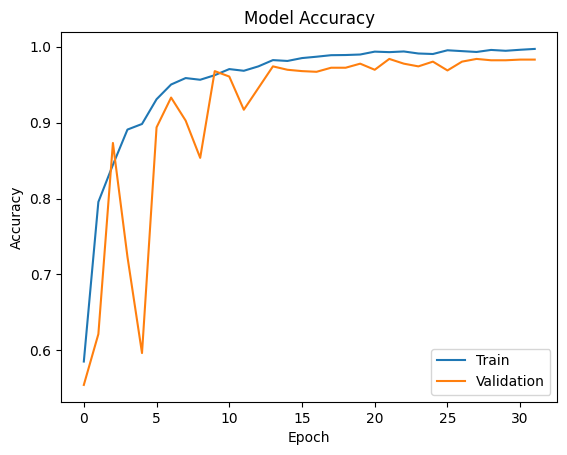

In [12]:
import matplotlib.pyplot as plt

# =========================================================
# VISUALIZATION ACCURACY
# =========================================================

plt.plot(history_best_trial.history['accuracy'])
plt.plot(history_best_trial.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

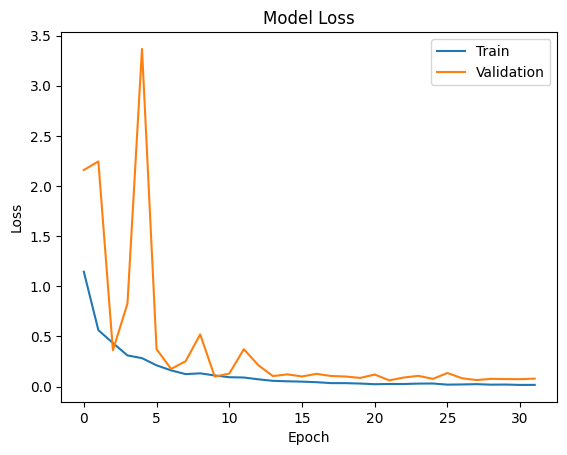

In [13]:
# =========================================================
# VISUALIZATION LOSS
# =========================================================

plt.plot(history_best_trial.history['loss'])
plt.plot(history_best_trial.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [19]:
# =========================================================
# TEST METRIC
# =========================================================

test_data.reset()
y_prob = model_best_trial.predict(test_data)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_data.classes

num_classes = y_prob.shape[1]
y_true_onehot = to_categorical(
    y_true,
    num_classes=num_classes
)

recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
auc = roc_auc_score(y_true_onehot, y_prob, average='weighted', multi_class='ovr')
accuracy = accuracy_score(y_true, y_pred)

print("\n================ MODEL =====================")
print(f"Model Recall       : {recall}")
print(f"Model AUC          : {auc}")
print(f"Model F1           : {f1}")
print(f"Model Accuracy     : {accuracy}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 371ms/step

================ MODEL =====================
Model Recall       : 0.949375
Model AUC          : 0.9925565104166667
Model F1           : 0.9484129668352574
Model Accuracy     : 0.949375


In [15]:
!pip install seaborn

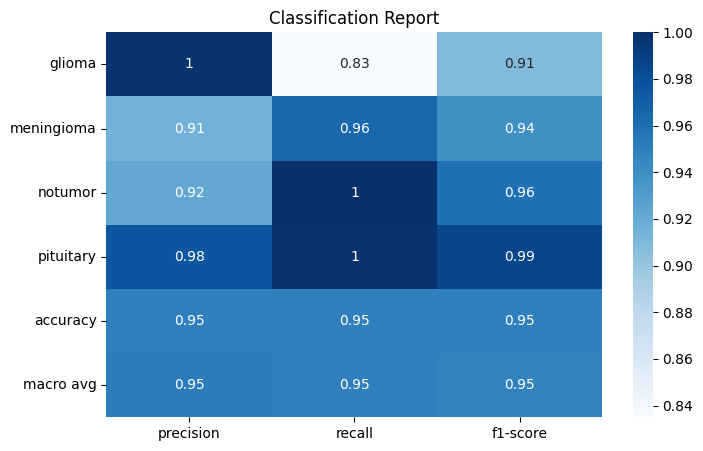

In [20]:
import pandas as pd
import seaborn as sns

class_names = list(train_data.class_indices.keys())
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)
df_report = pd.DataFrame(report_dict).transpose()
plt.figure(figsize=(8, 5))
sns.heatmap(
    df_report.iloc[:-1, :-1],
    annot=True,
    cmap='Blues'
)

plt.title("Classification Report")
plt.show()

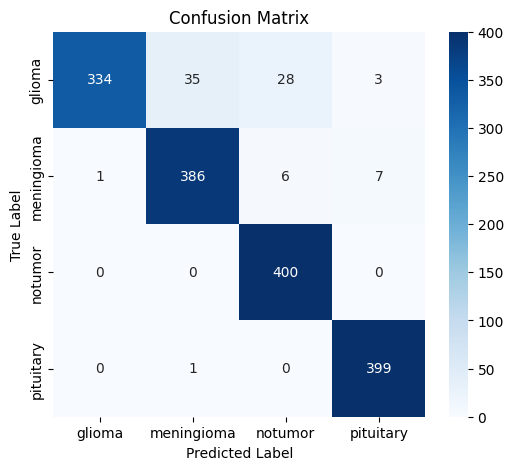

In [22]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()